## 1. Import lib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy import sparse
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_selection import chi2, f_classif, SelectFpr, SelectKBest
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
# from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Load dataset

In [4]:
df = pd.read_csv('/content/drive/Shareddrives/Học máy trong kinh doanh/Data/DataCoSupplyChainDataset.csv',encoding='latin-1')

## 3. EDA

In [5]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
df.shape

(180519, 53)

In [7]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

## Dataset Overview
- Records: 180,519 | Features: 53
- int64: 14 | float64: 15 | object: 24
## Issues
- Missing: Customer Lname (ít), Customer Zipcode (ít), Order Zipcode (nhiều), Product Description (toàn bộ → drop)
## Action
- Drop `Product Description`
- Xử lý/loại `Order Zipcode`
- Chuyển kiểu dữ liệu: Product Status: int64 → category, Late_delivery_risk: int64 → category

In [9]:
# Convert two variances dtype into category
df['Late_delivery_risk'] = df['Late_delivery_risk'].astype('category')
df['Delivery Status'] = df['Delivery Status'].astype('category')

In [10]:
# all features (identifier + categorical)
all_categorical_features = df.select_dtypes(include = ['object']).columns.tolist()
all_categorical_features

['Type',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Department Name',
 'Market',
 'Order City',
 'Order Country',
 'order date (DateOrders)',
 'Order Region',
 'Order State',
 'Order Status',
 'Product Image',
 'Product Name',
 'shipping date (DateOrders)',
 'Shipping Mode']

In [11]:
print(len(all_categorical_features))

23


### Category

Chia tất cả biến object thành hai biến: category + identifier

#### Categorical features

In [12]:
categorical_features = ['Type',  'Category Name',
            'Customer Segment', 'Market', 'Order City', 'Order Country',
            'Order State', 'Order Region', 'Order Status', 'Product Status',
            'Shipping Mode', 'Department Name',
            'Customer City', 'Customer Country', 'Customer State', 'Delivery Status']
print(len(categorical_features))

16


In [13]:
# convert type function
def convert_feature(df, features):
    for feature in features:
        df[feature] = df[feature].astype('category')
convert_feature(df, categorical_features)

#### Indentifier features

In [14]:
# all identifiers
identifier = ['Customer Name', 'Customer Street',
'Customer Email', 'Customer Fname', 'Customer Lname',
'Customer Password', 'order date (DateOrders)',
'Product Image', 'Product Name', 'shipping date (DateOrders)']
print(len(identifier))

10


In [15]:
# all features (identifier + categorical)
# test again
all_categorical_features_1 = df.select_dtypes(include = ['category', 'object']).columns.tolist()
print(len(all_categorical_features_1))

26


#### Visualize category

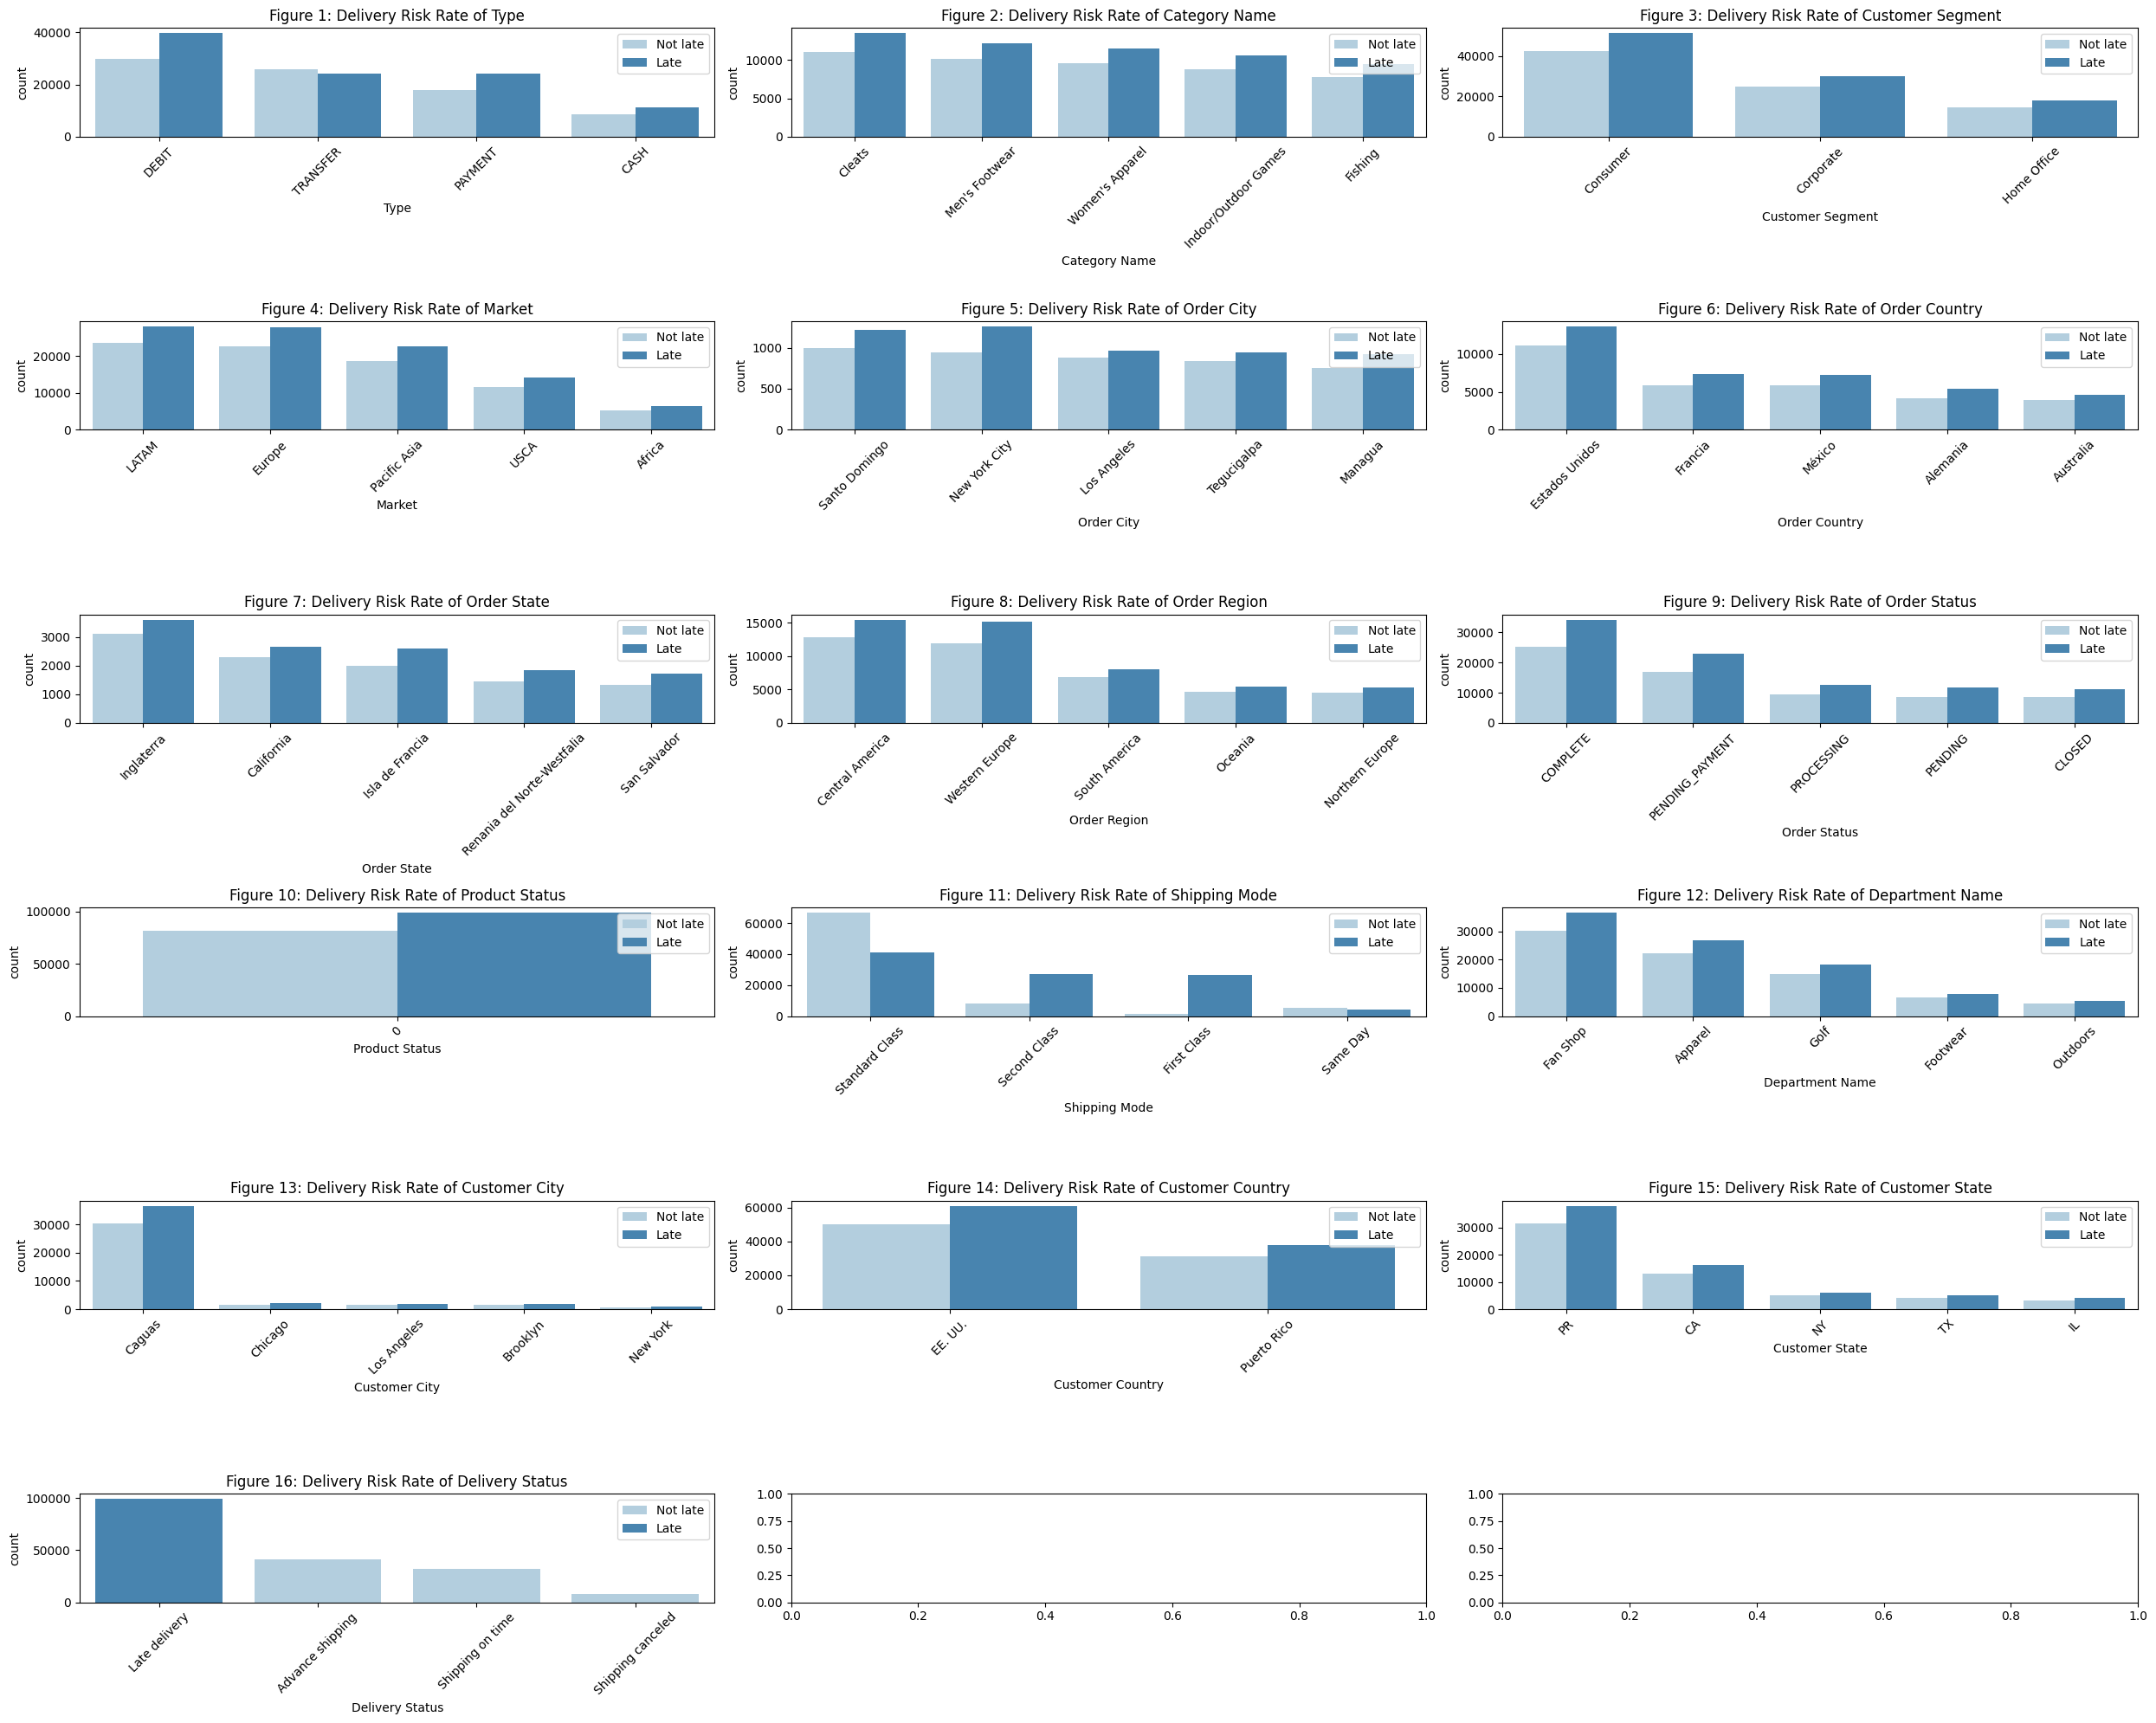

In [16]:
1404
n_rows = 6
n_cols = 3
fig, ax = plt.subplots(n_rows, n_cols, figsize = (25, 20))
for r in range (n_rows):
    for c in range (n_cols):
        i = r*n_cols + c
        if i < (len(categorical_features)):
            col = categorical_features[i]

            top_values = df[col].value_counts().nlargest(5).index
            df_top = df[df[col].isin(top_values)]

            sns.countplot(df_top, x = col, order = top_values, hue = 'Late_delivery_risk', palette = 'Blues', ax = ax[r][c])
            ax[r][c].set_title(f'Figure {i+1}: Delivery Risk Rate of {categorical_features[i]}')
            ax[r][c].legend(title = '', loc = 'upper right', labels = ['Not late', 'Late'])
            ax[r][c].tick_params(axis = 'x', rotation = 45)
plt.tight_layout()

Key Insights

- Fig 1: Transfer có nhiều đơn Not Late hơn; Debit có tổng đơn và số đơn Late cao nhất  
- Fig 3: Đơn hàng chủ yếu thuộc Consumer và cũng có số lượng Late cao nhất  
- Fig 4: LATAM và Europe là hai market có nhiều đơn giao trễ nhất  
- Fig 5: San Diego và New York là hai thành phố có tỷ lệ giao trễ cao  
- Fig 6: Estados Unidos có số đơn Not Late chiếm ưu thế rõ rệt  
- Fig 9: Ngay cả khi trạng thái là "Complete", rủi ro giao trễ vẫn cao  
- Fig 10: Tất cả đơn hàng đều ở trạng thái hết hàng  
- Fig 11: Standard Class có nhiều đơn nhất và tỷ lệ Not Late cao; 1st Class và 2nd Class có tỷ lệ Late cao hơn; Same Day ở mức trung bình  
- Fig 13: Caguas có số lượng đơn hàng vượt trội so với các thành phố khác  

### Numerical

In [17]:
numeric_cols = df.select_dtypes(include=['number'])
numeric_cols

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,Longitude,...,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price
0,3,4,91.250000,314.640015,73,20755,725.0,2,18.251453,-66.037056,...,0.29,1,327.750000,314.640015,91.250000,NaN,1360,73,NaN,327.750000
1,5,4,-249.089996,311.359985,73,19492,725.0,2,18.279451,-66.037064,...,-0.80,1,327.750000,311.359985,-249.089996,NaN,1360,73,NaN,327.750000
2,4,4,-247.779999,309.720001,73,19491,95125.0,2,37.292233,-121.881279,...,-0.80,1,327.750000,309.720001,-247.779999,NaN,1360,73,NaN,327.750000
3,3,4,22.860001,304.809998,73,19490,90027.0,2,34.125946,-118.291016,...,0.08,1,327.750000,304.809998,22.860001,NaN,1360,73,NaN,327.750000
4,2,4,134.210007,298.250000,73,19489,725.0,2,18.253769,-66.037048,...,0.45,1,327.750000,298.250000,134.210007,NaN,1360,73,NaN,327.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,4,4,40.000000,399.980011,45,1005,11207.0,7,40.640930,-73.942711,...,0.10,1,399.980011,399.980011,40.000000,NaN,1004,45,NaN,399.980011
180515,3,2,-613.770019,395.980011,45,9141,93304.0,7,35.362545,-119.018700,...,-1.55,1,399.980011,395.980011,-613.770019,NaN,1004,45,NaN,399.980011
180516,5,4,141.110001,391.980011,45,291,6010.0,7,41.629959,-72.967155,...,0.36,1,399.980011,391.980011,141.110001,NaN,1004,45,NaN,399.980011
180517,3,4,186.229996,387.980011,45,2813,725.0,7,18.213350,-66.370575,...,0.48,1,399.980011,387.980011,186.229996,NaN,1004,45,NaN,399.980011


#### Drop col

In [18]:
id_cols = [
    "Category Id",
    "Order Customer Id",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Product Card Id",
    "Product Category Id",
    "Customer Id",
    "Order Id",
    "Department Id"
]
zipcode_cols = [
    "Order Zipcode",
    "Customer Zipcode"
]
desc_cols = ["Product Description"]
leakage_cols = ["Days for shipping (real)"]
cols_to_drop = (
    id_cols
    + zipcode_cols
    + desc_cols
    + leakage_cols
)
df_clean = df.drop(columns=cols_to_drop, errors='ignore')


Heatmap này chứng minh việc loại bỏ các biến có tương quan cao tỪ phần Visualize numerical là chính xác
- VD: Sales/ Sales per customer

Giữ lại các biến numerical important:
- Ban đâu: Có 27 biến numerical
- Có 18 biến bình thường
- Có 9 biến ID -> Bỏ
- Bỏ biến OrderZipcode, CustomerZipcode: Mã định danh bưu điện
- Bỏ biến Product Description: ko có giá trị
- Bỏ hai biến 'Days for shipping (real)'--> overfitting model
- Bỏ Sales/ Product Price/ Order Profit Per Order/ Order Item Total/ Order Item Discount
--> Còn 9 biến


In [19]:
numeric_cols = df_clean.select_dtypes(include=['number'])
numeric_cols

,Days for shipment (scheduled),Benefit per order,Sales per customer,Latitude,Longitude,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
0,4,91.250000,314.640015,18.251453,-66.037056,13.110000,0.04,327.750000,0.29,1,327.750000,314.640015,91.250000,327.750000
1,4,-249.089996,311.359985,18.279451,-66.037064,16.389999,0.05,327.750000,-0.80,1,327.750000,311.359985,-249.089996,327.750000
2,4,-247.779999,309.720001,37.292233,-121.881279,18.030001,0.06,327.750000,-0.80,1,327.750000,309.720001,-247.779999,327.750000
3,4,22.860001,304.809998,34.125946,-118.291016,22.940001,0.07,327.750000,0.08,1,327.750000,304.809998,22.860001,327.750000
4,4,134.210007,298.250000,18.253769,-66.037048,29.500000,0.09,327.750000,0.45,1,327.750000,298.250000,134.210007,327.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,4,40.000000,399.980011,40.640930,-73.942711,0.000000,0.00,399.980011,0.10,1,399.980011,399.980011,40.000000,399.980011
180515,2,-613.770019,395.980011,35.362545,-119.018700,4.000000,0.01,399.980011,-1.55,1,399.980011,395.980011,-613.770019,399.980011
180516,4,141.110001,391.980011,41.629959,-72.967155,8.000000,0.02,399.980011,0.36,1,399.980011,391.980011,141.110001,399.980011
180517,4,186.229996,387.980011,18.213350,-66.370575,12.000000,0.03,399.980011,0.48,1,399.980011,387.980011,186.229996,399.980011


In [20]:
df_numeric = df_clean.drop(columns=["Product Status"], errors="ignore") \
                     .select_dtypes(include=["number"])
df_numeric.columns

Index(['Days for shipment (scheduled)', 'Benefit per order',
       'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Product Price'],
      dtype='object')

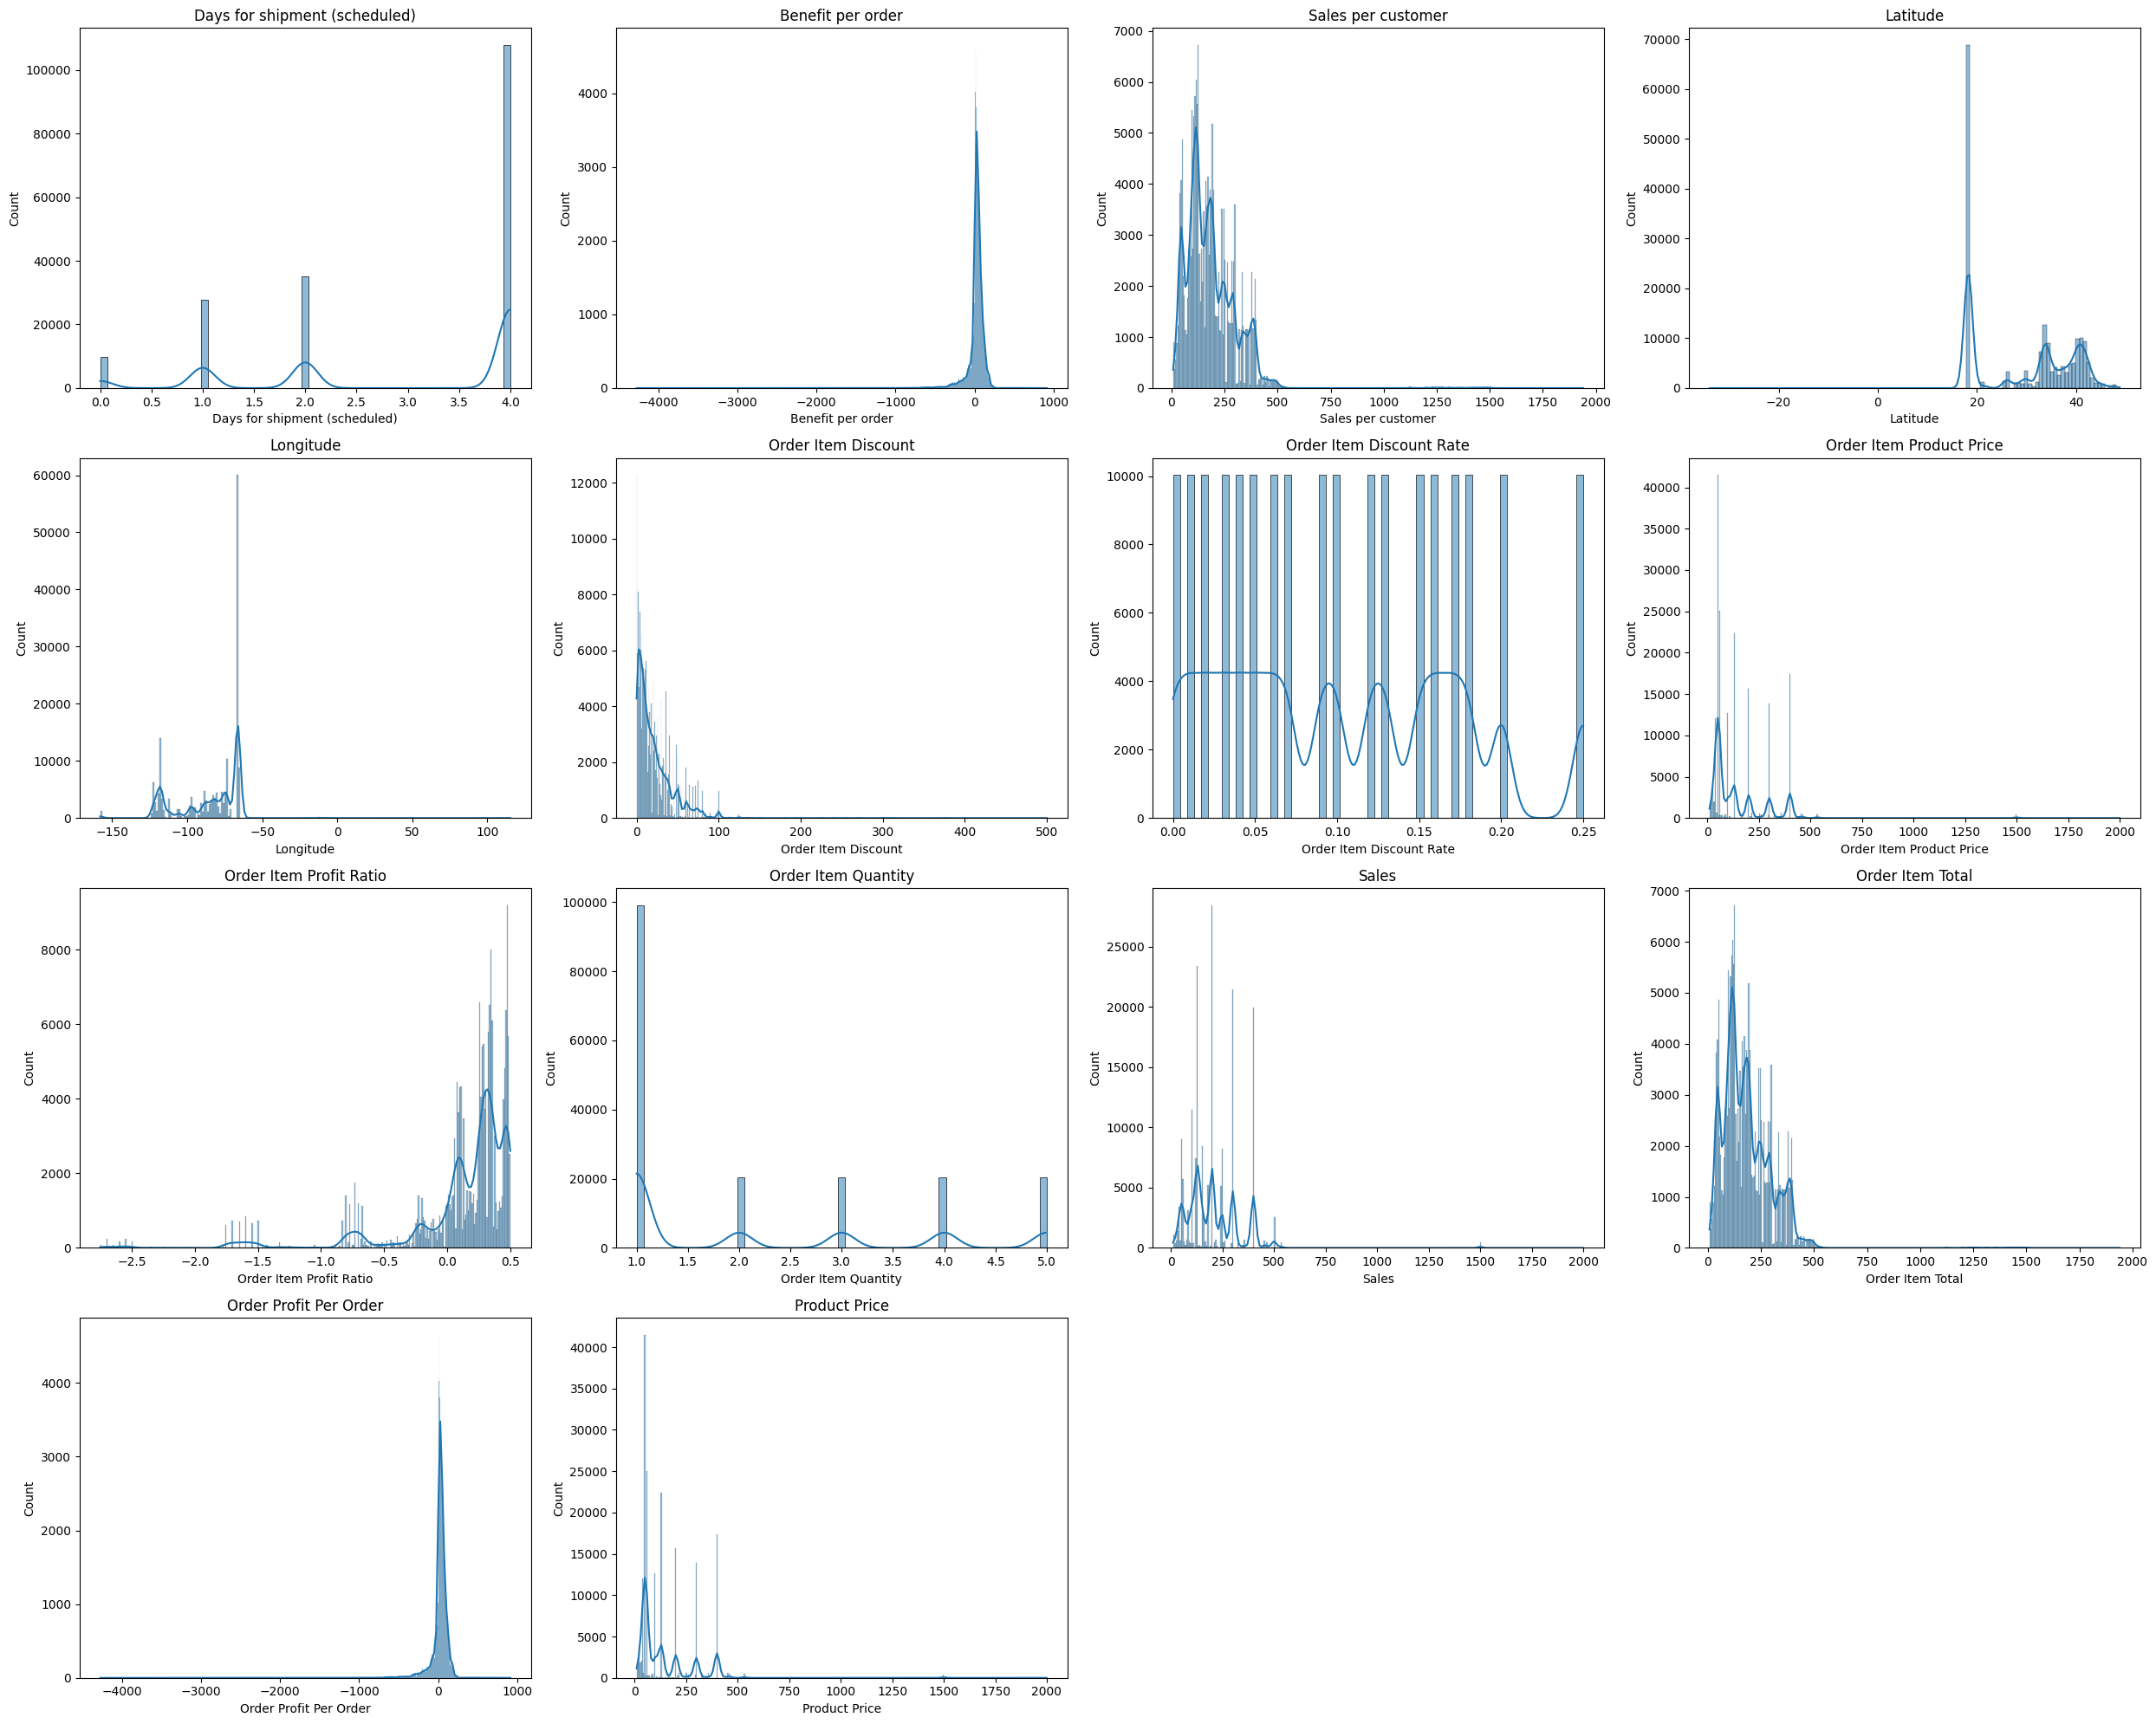

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numeric_cols = df_numeric.columns.tolist()

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(25, 5 * n_rows))

ax = ax.flatten()  # trải phẳng mảng 2D thành 1D

for i, col in enumerate(numeric_cols):
    sns.histplot(df_numeric[col].dropna(), kde=True, ax=ax[i])
    ax[i].set_title(col)

# Xóa subplot trống (nếu có)
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

Key Insights

- Fig 3 & Fig 11: `Sales per customer` và `Sales` có phân phối tương tự → giữ `Sales per customer`  
- Fig 8 & Fig 14: `Order Item Product Price` và `Product Price` tương tự → giữ `Order Item Product Price`  
- Fig 2 & Fig 9 & Fig 12: `Benefit per order`, `Order Profit Per Order`, `Order Item Total` tương tự → giữ `Benefit per order`  
- Fig 6 & Fig 7: `Order Item Discount Rate` được tính từ `Order Item Discount` → giữ `Order Item Discount Rate`  